# Exercise 7: Boosting and Gradient Boosting


```{admonition} Run or download this notebook
:class: how-to-use

This page is fully readable as it is, and the interactive activities work
here in the browser. To **run or change the Python code**, use the portable
version of the notebook:

- **[Open the portable notebook in Colab](https://colab.research.google.com/github/yoavmp/ml-neuro-tutorials/blob/main/book/downloads/chapter_07/exercise_07_portable.ipynb)**
- **[View or download the portable `.ipynb`](https://raw.githubusercontent.com/yoavmp/ml-neuro-tutorials/main/book/downloads/chapter_07/exercise_07_portable.ipynb)**
  for VS Code or Jupyter

The portable notebook keeps every Python analysis cell and swaps each
embedded activity for a link back to this page.
```


## What this notebook covers

This is Exercise 7 of *Machine Learning for Neuroscience*. Exercise 6 compared
one tree with ensembles built by averaging many **independently** trained
trees (bagging and Random Forest). Exercise 7 asks what happens when trees
are instead built **sequentially**, with each new tree correcting errors
left by the existing model -- **boosting**.

In this notebook you will:

1. distinguish boosting from bagging;
2. follow residual correction tree by tree;
3. explore learning rate, number of trees, and tree depth;
4. choose settings using development data and evaluate a locked test set once;
5. compare a single tree, Random Forest, and gradient boosting.

Gradient boosting is not guaranteed to outperform Random Forest -- both are
strong tree-ensemble methods, and which one validates better depends on the
task and dataset.

**Prerequisites:** Exercise 6 (regression trees, bagging, and Random Forest).


## 1. From Bagging to Boosting

| Method | How trees are trained | Combined prediction | Main idea |
|---|---|---|---|
| Single tree | One tree | One prediction | Simple model |
| Bagging | Independently on resampled data | Average | Reduce variance |
| Random Forest | Independently with row and feature randomness | Average | Decorrelate trees |
| Gradient boosting | Sequentially to correct current errors | Weighted sum | Improve the model step by step |


A few key points:

- bagging trees can be trained independently, and in any order -- boosting
  trees cannot, because each one depends on the predictions of every tree
  fitted before it;
- individual boosting trees are usually shallow (often just a few splits, or
  even a single split);
- a long sequence of shallow trees can nonetheless combine into a complex,
  nonlinear model;
- sequential correction also creates its own overfitting risk: nothing stops
  the sequence from eventually fitting noise specific to the training data.


```{admonition} Think first
:class: think-first
- Bagging averages many independently trained trees. Why does averaging not
  necessarily correct a bias every one of those trees shares?
- What risk arises from adding corrective trees indefinitely?
```


In [1]:
# Data loading. In the published book this cell is collapsed; it is plain,
# runnable Python -- one public CSV pinned to an immutable commit. This is
# the exact same ABIDE-II table Exercises 2, 4, 5, and 6 use, with age as a
# native column.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, DecisionTreeRegressor as _DTR

PIN = "e4eed3c4daa7f40b0ba931182a8c7e5e691dba6b"
BASE = f"https://raw.githubusercontent.com/neurohackademy/nh2020-curriculum/{PIN}/tu-machine-learning-yarkoni/data"

model_df = pd.read_csv(f"{BASE}/abide2.tsv", sep="\t")
model_df = model_df.loc[:, [c for c in model_df.columns if not str(c).startswith("Unnamed")]]

BRAIN_COLS = [c for c in model_df.columns if c.startswith("fs")]
print(f"data table: {model_df.shape[0]} participants x {model_df.shape[1]} columns")


data table: 1004 participants x 1446 columns


In [2]:
# The same fixed 360 cortical-thickness predictors and fixed, stratified
# train/test split used throughout Exercises 2, 4, 5, and 6. The further
# split of the training partition below (identical to Exercise 6's own
# fitting/validation split) is reused for every development-only step in
# this notebook; the test set is read exactly once, in section 6.
FEATURES = [c for c in BRAIN_COLS if c.startswith("fsCT_")]
assert all(c.startswith("fsCT_") for c in FEATURES)
assert "age" not in FEATURES

has_age = model_df["age"].notna()
X = model_df.loc[has_age, FEATURES].to_numpy(float)
y = model_df.loc[has_age, "age"].to_numpy(float)
groups = model_df.loc[has_age, "group"].to_numpy()

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.25, random_state=42, stratify=groups
)
X_fit, X_val, y_fit, y_val, groups_fit, groups_val = train_test_split(
    X_train, y_train, groups_train, test_size=0.25, random_state=7, stratify=groups_train
)
print(f"{len(FEATURES)} predictors")
print(f"n_fit = {len(y_fit)}   n_val = {len(y_val)}   "
      f"n_train (development) = {len(y_train)}   n_test = {len(y_test)} (locked; read once, in section 6)")


360 predictors
n_fit = 564   n_val = 189   n_train (development) = 753   n_test = 251 (locked; read once, in section 6)


## 2. Building a Model One Tree at a Time

Squared-error gradient boosting builds its prediction $\hat y$ in stages.
The first stage predicts the training-target mean for every observation:

$$
\hat y_i^{(0)} = \bar y
$$

Before adding stage $m$, the **residual** left by the current model is

$$
r_i^{(m)} = y_i - \hat y_i^{(m-1)}
$$

A new shallow tree $f_m$ is fitted to predict these residuals, and the
model is updated by adding a **learning-rate-scaled** copy of that tree:

$$
\hat y_i^{(m)} = \hat y_i^{(m-1)} + \eta \, f_m(x_i)
$$

In plain language:

- the first model predicts the training-target mean;
- the next shallow tree predicts the current **residuals** -- not the
  target itself;
- the learning rate $\eta$ controls how much of that correction is added at
  each step;
- residuals are recalculated after every update, so the next tree always
  targets whatever error remains.

We will not derive this update in general; it is enough to know that, for
squared error specifically, the negative gradient of the loss with respect
to the current prediction is exactly the residual above -- which is why
this procedure is called *gradient* boosting.


### Interactive Activity 1: Build a Boosted Model

The activity below uses a small, **simulated** dataset -- 24 observations on
one continuous predictor, generated from a fixed formula and seed so the
relationship is visible but noisy, not a clean curve. These are simulated
values used to understand the algorithm, not ABIDE observations. Choose a
learning rate, then step through the boosting stages: the top panel shows
the observations and the current ensemble prediction; the middle panel
shows the residuals left before this update and the shallow regression
stump (a tree with a single split) fitted to them; the bottom panel tracks
training MSE across every stage.


<iframe
  title="Interactive stage-by-stage gradient boosting activity on a small simulated dataset"
  src="../../_static/widgets/app/index.html?config=../configs/boosting_step_by_step.json"
  loading="lazy"
  width="100%"
  height="1500"
  class="ml-activity"
  style="width: 100%;"
></iframe>


In [3]:
# Optional: a compact Python reproduction of the activity's simulated
# dataset and its first boosting stage, computed from the exact same fixed
# formula and seed as the widget's own committed data artifact.
STEP_SEED = 7
STEP_N = 24
C, A, FREQ, B, NOISE_SD = 5.0, 4.0, 0.9, 0.6, 1.2

rng = np.random.RandomState(STEP_SEED)
step_x = rng.uniform(0.0, 10.0, size=STEP_N)
step_noise = rng.normal(0.0, NOISE_SD, size=STEP_N)
step_y = C + A * np.sin(FREQ * step_x) + B * step_x + step_noise

stage0_prediction = np.full(STEP_N, step_y.mean())
residual_before_stage1 = step_y - stage0_prediction
print(f"stage 0 prediction (training mean) = {stage0_prediction[0]:.3f}")
print(f"stage 0 training MSE = {np.mean(residual_before_stage1 ** 2):.2f}")

stump = DecisionTreeRegressor(max_depth=1, random_state=0)
stump.fit(step_x.reshape(-1, 1), residual_before_stage1)
eta = 0.3
stage1_prediction = stage0_prediction + eta * stump.predict(step_x.reshape(-1, 1))
print(f"stage 1 training MSE (eta={eta}) = {mean_squared_error(step_y, stage1_prediction):.2f}")


stage 0 prediction (training mean) = 8.454
stage 0 training MSE = 16.20
stage 1 training MSE (eta=0.3) = 10.42


## 3. Gradient Boosting with Scikit-Learn

Scikit-learn's `GradientBoostingRegressor` implements the same procedure
directly:


In [4]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
)

gb_model.fit(X_fit, y_fit)
predictions = gb_model.predict(X_val)
print(f"validation MSE = {mean_squared_error(y_val, predictions):.1f}   "
      f"validation R2 = {r2_score(y_val, predictions):.3f}")


validation MSE = 18.2   validation R2 = 0.747


| Parameter | Meaning | Effect of increasing it |
|---|---|---|
| `n_estimators` | Number of sequential trees | More corrections and greater overfitting risk |
| `learning_rate` | Contribution of each new tree | Faster, less cautious updates |
| `max_depth` | Complexity of each tree | More complex corrections |
| `subsample` | Fraction of training rows per tree | Adds randomness below 1 |

The first three matter most for this exercise. Like every tree-based model
in this course, gradient boosting does **not** require feature scaling.


## 4. Learning Rate and Number of Trees

`n_estimators` and `learning_rate` interact: a smaller learning rate makes
each individual correction more cautious, so it typically needs more trees
to reach a comparable fit. `max_depth` changes how complex each individual
correction can be.


### Interactive Activity 2: Explore the Boosting Parameters

This activity uses only the fixed 564-participant fitting subset and
189-participant validation subset from the outer development partition --
the same development split used above. **The locked outer test set is never
part of this activity**, and lower training MSE does not automatically mean
better validation performance. Choose a learning rate and a tree depth,
then use the number-of-trees control -- or press **Play** to add trees
sequentially -- and watch training/validation MSE, the learning-rate x
tree-count heatmap, and the observed-versus-predicted plot update together.


<iframe
  title="Interactive gradient-boosting parameter explorer for predicting age from brain structure"
  src="../../_static/widgets/app/index.html?config=../configs/boosting_parameter_explorer.json"
  loading="lazy"
  width="100%"
  height="1700"
  class="ml-activity"
  style="width: 100%;"
></iframe>


## 5. Choosing When to Stop

The curve below refits one configuration from the activity above (learning
rate 0.1, depth 2) across every tree count up to 300, using scikit-learn's
`staged_predict` so only one model needs to be fit.


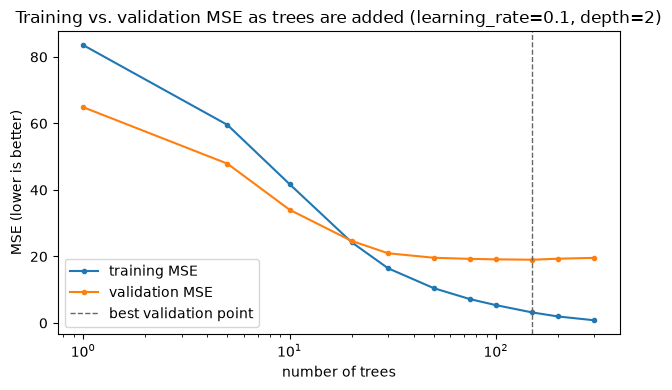

n_trees=   1  train MSE= 83.55  val MSE= 64.88
n_trees=   5  train MSE= 59.56  val MSE= 47.90
n_trees=  10  train MSE= 41.75  val MSE= 34.05
n_trees=  20  train MSE= 24.26  val MSE= 24.67
n_trees=  30  train MSE= 16.45  val MSE= 20.97
n_trees=  50  train MSE= 10.47  val MSE= 19.61
n_trees=  75  train MSE=  7.16  val MSE= 19.27
n_trees= 100  train MSE=  5.37  val MSE= 19.13
n_trees= 150  train MSE=  3.17  val MSE= 19.02  <- lowest validation MSE
n_trees= 200  train MSE=  1.96  val MSE= 19.33
n_trees= 300  train MSE=  0.81  val MSE= 19.58


In [5]:
stop_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=2, random_state=42)
stop_model.fit(X_fit, y_fit)

stop_n_trees = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300]
stop_train_pred = list(stop_model.staged_predict(X_fit))
stop_val_pred = list(stop_model.staged_predict(X_val))
stop_train_mse = [mean_squared_error(y_fit, stop_train_pred[n - 1]) for n in stop_n_trees]
stop_val_mse = [mean_squared_error(y_val, stop_val_pred[n - 1]) for n in stop_n_trees]
best_i = int(np.argmin(stop_val_mse))

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(stop_n_trees, stop_train_mse, marker=".", label="training MSE")
ax.plot(stop_n_trees, stop_val_mse, marker=".", label="validation MSE")
ax.axvline(stop_n_trees[best_i], color="0.4", ls="--", lw=1, label="best validation point")
ax.set_xscale("log")
ax.set_xlabel("number of trees")
ax.set_ylabel("MSE (lower is better)")
ax.set_title("Training vs. validation MSE as trees are added (learning_rate=0.1, depth=2)")
ax.legend()
plt.tight_layout()
plt.show()

for n, tr, va in zip(stop_n_trees, stop_train_mse, stop_val_mse):
    marker = "  <- lowest validation MSE" if n == stop_n_trees[best_i] else ""
    print(f"n_trees={n:4d}  train MSE={tr:6.2f}  val MSE={va:6.2f}{marker}")


Training MSE keeps falling as more trees are added -- it reaches a small
fraction of its starting value by 300 trees. Validation MSE instead falls
quickly at first, flattens out, and then rises slightly: past that point,
additional trees keep correcting residuals specific to the training
participants rather than improving the underlying fit. This is the same
underfitting-then-overfitting pattern Exercise 6 showed for tree depth --
here it plays out across the number of boosting stages instead. Validation
performance, not minimum training error, is what should guide how many
trees to keep. This is the basic idea behind **early stopping**: monitoring
validation error and halting once it stops improving, rather than always
training the full requested number of trees.

**Question:** if 300 trees have lower training MSE but higher validation
MSE than 120 trees, which model should be selected, and why?


## 6. A Complete Gradient-Boosting Pipeline

We now apply Exercise 4's validation logic, without reteaching it: preserve
the locked outer test, tune only on the development partition, and touch the
test set exactly once.

1. preserve the locked outer test set;
2. run cross-validation only within the outer development partition;
3. compare a small parameter grid;
4. select one configuration by mean CV MSE;
5. refit it on all development participants;
6. evaluate the locked test set exactly once.


The grid we intended to compare was:

```python
parameter_grid = {
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [50, 100, 200],
    "max_depth": [1, 2, 3],
}
```

This is 27 candidates. Audited on the target machine, a 5-fold
cross-validation of the full 27-candidate grid took roughly 357 seconds --
disproportionate next to every other audit in this course (all under 35
seconds). Following the predeclared rule for this situation, the grid was
reduced once, before any candidate was scored, to a fixed 12-candidate
subset: all 3 depths crossed with 4 representative
(`learning_rate`, `n_estimators`) pairs spanning low, medium, and high
cost -- never a subset chosen by inspecting which omitted settings would
have helped. That reduced grid took roughly 140 seconds.


In [6]:
# Reduced, predeclared 12-candidate grid (see the markdown above for why).
lr_n_estimators_pairs = [(0.03, 50), (0.05, 100), (0.1, 100), (0.1, 200)]
depth_grid = [1, 2, 3]
candidate_grid = [
    {"learning_rate": lr, "n_estimators": n, "max_depth": d}
    for d in depth_grid
    for lr, n in lr_n_estimators_pairs
]

cv = KFold(n_splits=5, shuffle=True, random_state=13)
fold_splits = list(cv.split(X_train))

cv_rows = []
for candidate in candidate_grid:
    fold_mse = []
    for train_idx, val_idx in fold_splits:
        m = GradientBoostingRegressor(random_state=42, **candidate)
        m.fit(X_train[train_idx], y_train[train_idx])
        fold_mse.append(mean_squared_error(y_train[val_idx], m.predict(X_train[val_idx])))
    cv_rows.append({**candidate, "mean_cv_mse": float(np.mean(fold_mse))})

cv_results_df = pd.DataFrame(cv_rows)
best_row = cv_results_df.loc[cv_results_df["mean_cv_mse"].idxmin()]
selected_params = {k: (int(best_row[k]) if k != "learning_rate" else float(best_row[k])) for k in ["learning_rate", "n_estimators", "max_depth"]}

final_gb_model = GradientBoostingRegressor(random_state=42, **selected_params).fit(X_train, y_train)
gb_test_pred = final_gb_model.predict(X_test)
gb_test_mse = mean_squared_error(y_test, gb_test_pred)
gb_test_r2 = r2_score(y_test, gb_test_pred)


In [7]:
print("cross-validation results (development partition only):")
display(cv_results_df.round(2))
print(f"\nselected settings: {selected_params}  (mean CV MSE = {best_row['mean_cv_mse']:.1f})")
print(f"locked-test MSE = {gb_test_mse:.1f}   locked-test R2 = {gb_test_r2:.3f}  (evaluated once)")


cross-validation results (development partition only):


,learning_rate,n_estimators,max_depth,mean_cv_mse
0,0.03,50,1,55.04
1,0.05,100,1,36.54
2,0.10,100,1,31.26
3,0.10,200,1,28.67
4,0.03,50,2,43.63
5,0.05,100,2,29.64
6,0.10,100,2,28.54
7,0.10,200,2,27.64
8,0.03,50,3,39.12
9,0.05,100,3,28.98



selected settings: {'learning_rate': 0.1, 'n_estimators': 200, 'max_depth': 3}  (mean CV MSE = 27.2)
locked-test MSE = 32.4   locked-test R2 = 0.653  (evaluated once)


The selected configuration is the one with the lowest mean cross-validation
MSE on development data alone; the test set played no part in choosing it,
and is read here for the first and only time in this notebook.


## 7. Comparing Tree-Based Models

Finally, we compare a single regression tree, a Random Forest, and the
selected gradient-boosting model above, all on the **identical** participant
split (this notebook's outer development partition and locked test set),
the same 360 features, and the same target. The single tree and Random
Forest use Exercise 6's own complexity settings, carried forward unchanged
rather than retuned for this comparison.


In [8]:
fair_tree_settings = dict(max_depth=6, min_samples_leaf=5, random_state=42)
fair_n_estimators = 50
fair_max_features = 19  # carried forward from Exercise 6, not retuned here

single_tree = _DTR(**fair_tree_settings).fit(X_train, y_train)
single_tree_pred = single_tree.predict(X_test)

random_forest = RandomForestRegressor(
    n_estimators=fair_n_estimators,
    max_features=fair_max_features,
    random_state=fair_tree_settings["random_state"],
    max_depth=fair_tree_settings["max_depth"],
    min_samples_leaf=fair_tree_settings["min_samples_leaf"],
).fit(X_train, y_train)
random_forest_pred = random_forest.predict(X_test)


In [9]:
comparison_rows = [
    {"Model": "Single tree", "Locked-test MSE": mean_squared_error(y_test, single_tree_pred),
     "Locked-test R2": r2_score(y_test, single_tree_pred)},
    {"Model": "Random Forest", "Locked-test MSE": mean_squared_error(y_test, random_forest_pred),
     "Locked-test R2": r2_score(y_test, random_forest_pred)},
    {"Model": "Gradient boosting", "Locked-test MSE": gb_test_mse, "Locked-test R2": gb_test_r2},
]
pd.DataFrame(comparison_rows).set_index("Model").round(3)


,Locked-test MSE,Locked-test R2
Model,,
Single tree,70.132,0.249
Random Forest,38.199,0.591
Gradient boosting,32.368,0.653


On this cohort, this split, and these settings, gradient boosting achieves
the lowest locked-test MSE of the three, followed by the Random Forest, with
the single tree well behind both -- a **consistent held-out comparison**,
not proof that gradient boosting universally wins: a different task,
cohort, or set of settings could easily favor the Random Forest instead.


```{dropdown} Where does XGBoost fit?
XGBoost is an efficient, regularized implementation of gradient-boosted
trees. It follows the same broad sequential-correction principle taught in
this notebook, but adds computational optimizations and extra
regularization terms that are especially useful for tabular data.
Understanding ordinary gradient boosting, as covered here, is the right
place to start before reaching for XGBoost.

A minimal example, for reference only -- this notebook does not install,
import, or execute `xgboost`:

    from xgboost import XGBRegressor

    xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42)
    xgb_model.fit(X_fit, y_fit)
```


## 8. What Should We Remember?

- Boosting builds trees sequentially, unlike bagging and Random Forest,
  which build trees independently.
- Each shallow tree corrects the residuals left by the current model.
- The learning rate controls the size of each correction.
- Learning rate and number of trees must be considered together: a smaller
  learning rate usually needs more trees.
- Validation data, not training error, guides both when to stop adding
  trees and which settings to choose.
- The test set is used exactly once, after every choice has already been
  fixed from development data alone.

### Questions to take away

1. How does boosting differ from bagging?
2. What does each new tree predict for squared-error gradient boosting?
3. Why does a smaller learning rate usually require more trees?
4. Why can training MSE improve while validation MSE becomes worse?
5. Why must the test set remain hidden while choosing the learning rate and
   number of trees?
6. Is XGBoost a completely different principle, or an extension of
   gradient boosting?
